# Практика 5 Прогнозирование стоимости жилья
Использую предоставленный California Housing в файле `housing.csv`. Ответ `median_house_value` — медианная стоимость жилья района в долларах. Модель оценивает район, а не конкретную квартиру. Для наглядности выбираю три признака: медианный доход, возраст домов и число комнат на домохозяйство.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')


df=pd.read_csv(BASE/'data'/'housing.csv')
# Среднее число комнат на домохозяйство удобнее общего числа комнат района.
df['rooms_per_household']=df['total_rooms']/df['households']
features=['median_income','housing_median_age','rooms_per_household']
target='median_house_value'
data=df[features+[target]].replace([np.inf,-np.inf],np.nan).dropna()
X,y=data[features],data[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

Python: 3.10.20


Размер исходной таблицы: 20640 строк, 10 исходных столбцов


,Тип,Пропуски
longitude,float64,0
latitude,float64,0
housing_median_age,float64,0
total_rooms,float64,0
total_bedrooms,float64,207
population,float64,0
households,float64,0
median_income,float64,0
median_house_value,float64,0
ocean_proximity,object,0


Для модели: (20640, 4)


,median_income,housing_median_age,rooms_per_household,median_house_value
0,8.3252,41.0,6.984127,452600.0
1,8.3014,21.0,6.238137,358500.0
2,7.2574,52.0,8.288136,352100.0
3,5.6431,52.0,5.817352,341300.0
4,3.8462,52.0,6.281853,342200.0


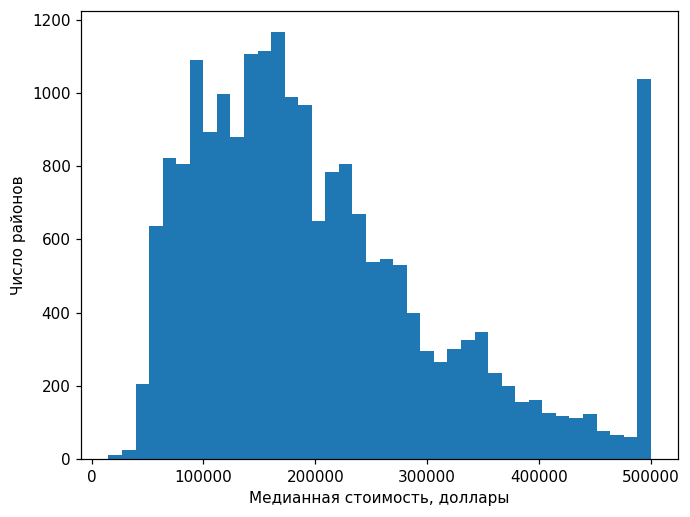

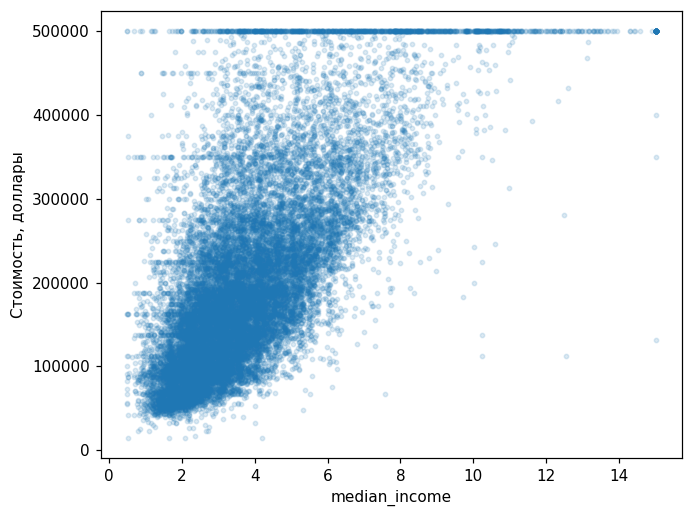

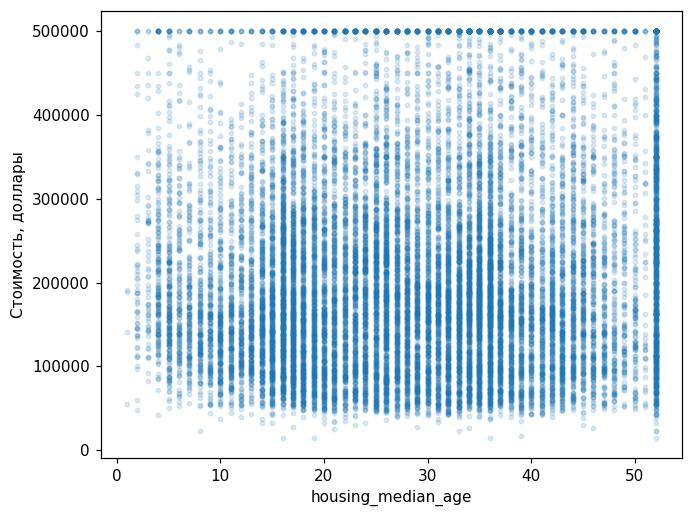

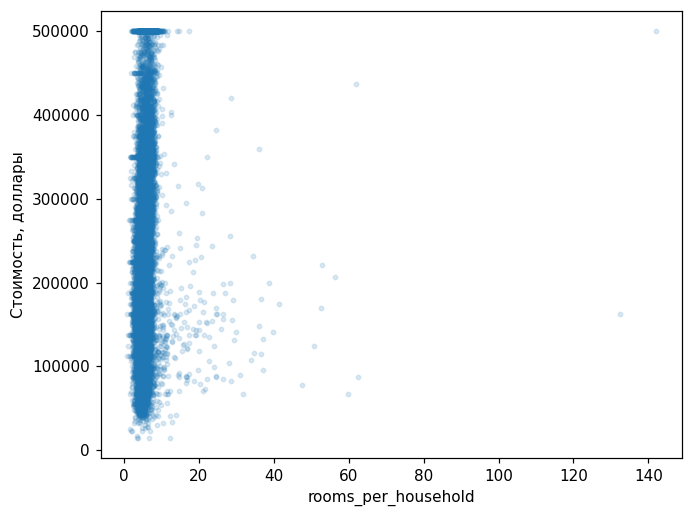

In [2]:
print('Размер исходной таблицы:',df.shape[0], 'строк, 10 исходных столбцов')
display(pd.DataFrame({'Тип':df.dtypes.astype(str),'Пропуски':df.isna().sum()}))
print('Для модели:',data.shape)
display(data.head())
plt.hist(y,bins=40)
plt.xlabel('Медианная стоимость, доллары');plt.ylabel('Число районов')
save_plot('p5_target.png')
for feature in features:
    plt.scatter(data[feature],y,alpha=0.15,s=8)
    plt.xlabel(feature);plt.ylabel('Стоимость, доллары')
    save_plot('p5_'+feature+'.png')

## Линейная модель и дерево
Доход связан с платёжеспособностью района. Возраст и комнатность помогают описать жильё. Это объяснение выбора признаков, а не доказательство причинности. Пропуски `total_bedrooms` не влияют на эту модель, потому что я не использую данный столбец. Сравниваю обе модели на одних данных.

,Модель,MAE,MSE,R2
0,LinearRegression,59680.467861,6.396642e+09,0.512652
1,DecisionTree depth=3,61407.721092,6.761871e+09,0.484826


,Признак,Коэффициент
0,median_income,44191.755888
1,housing_median_age,1683.784718
2,rooms_per_household,-2551.412570


Свободный член: 1357.4378569971304
При росте median_income на 1 единицу прогноз меняется на 44191.76 долларов при прочих равных.
Коэффициент median_income относится к одной единице исходной шкалы этого признака.


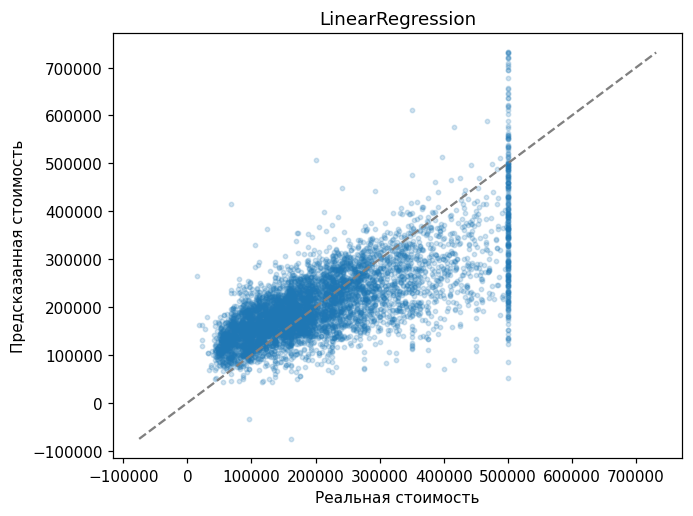

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
models={'LinearRegression':LinearRegression(),
        'DecisionTree depth=3':DecisionTreeRegressor(max_depth=3,random_state=42)}
rows=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    rows.append({'Модель':name,'MAE':mean_absolute_error(y_test,pred),
                 'MSE':mean_squared_error(y_test,pred),'R2':r2_score(y_test,pred)})
results=pd.DataFrame(rows)
display(results)
results.to_csv(BASE/'results'/'practice5.csv',index=False)
linear=models['LinearRegression']
coef=pd.DataFrame({'Признак':features,'Коэффициент':linear.coef_})
display(coef)
print('Свободный член:',linear.intercept_)
print('При росте median_income на 1 единицу прогноз меняется на',round(linear.coef_[0],2),'долларов при прочих равных.')
print('Коэффициент median_income относится к одной единице исходной шкалы этого признака.')
best_name=results.sort_values('R2',ascending=False).iloc[0]['Модель']
best_pred=models[best_name].predict(X_test)
plt.scatter(y_test,best_pred,s=8,alpha=0.2)
limits=[min(y_test.min(),best_pred.min()),max(y_test.max(),best_pred.max())]
plt.plot(limits,limits,'--',color='grey')
plt.xlabel('Реальная стоимость');plt.ylabel('Предсказанная стоимость')
plt.title(best_name)
save_plot('p5_actual_predicted.png')
save_json('practice5.json',{'best_model':best_name,'coefficients':dict(zip(features,linear.coef_.tolist())),
    'intercept':float(linear.intercept_)})

## Вывод
MAE показывает среднюю ошибку в долларах, MSE сильнее учитывает крупные ошибки и измеряется в квадрате долларов. R² сравнивает модель с прогнозом среднего значения и не является процентом правильно угаданных цен. На выбранных трёх признаках линейная модель оказалась лучше дерева глубины 3. Отрицательный коэффициент комнатности описывает связь при фиксированных других признаках и не означает, что дополнительные комнаты сами по себе уменьшают цену.